In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
import requests

url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    words = response.text.replace(".", "").lower().splitlines()
    print(f"Downloaded {len(words)} names.")
    # print(words[:100])  # Show first 100 characters
else:
    print("Failed to download the file.")

Downloaded 55689 names.


In [3]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# Building a Dataset

import torch
import random

block_size = 3

def build_dataset(words):
  print(len(words))
  X = []
  Y = []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

44551
5569
5569


In [5]:
# MLP Revisted

n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(vocab_size, n_embd,             generator=g, requires_grad=True)
W1 = torch.randn(n_embd * block_size, n_hidden ,generator=g, requires_grad=True)
b1 = torch.randn(n_hidden,                      generator=g, requires_grad=True)
W2 = torch.randn(n_hidden, vocab_size,          generator=g, requires_grad=True)
b2 = torch.randn(vocab_size,                    generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
# print("Model initilised..")
print(f"Hidden Layers : {n_hidden}, embedding_dims : {n_embd}, input_values {vocab_size}, output_values: {vocab_size}")
print(f"Number of parameters in model {sum(p.nelement() for p in parameters)}") # Number of parameters in model

for p in parameters:
    p.requires_grad = True

Hidden Layers : 200, embedding_dims : 10, input_values 27, output_values: 27
Number of parameters in model 11897


In [6]:

max_steps = 20000
batch_size = 32
lossi = []

# Lets run for 30000 iterations on XTr (Xtrain)
for i in range(max_steps):
    
    # Mini batch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,)) # We will form minibatch using this
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch x,y


    # Forward pass
    emb = C[Xb] # (37,3, 2) # Embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre activation
    h = torch.tanh(hpreact) # (37,100)  # hidden layer
    logits = h @ W2 + b2 # 37,27 # output layer
    # loss
    loss = F.cross_entropy(logits, Yb)

    
    # Backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    
    # Update parameters
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad


    # Track Status
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
    lossi.append(loss.log10().item())

    

      0/  20000: 25.072968
   1000/  20000: 3.107212
   2000/  20000: 2.896522
   3000/  20000: 3.043123
   4000/  20000: 2.276956
   5000/  20000: 2.583012
   6000/  20000: 2.162865
   7000/  20000: 2.738580
   8000/  20000: 2.728959
   9000/  20000: 2.141176
  10000/  20000: 1.955814
  11000/  20000: 2.101968
  12000/  20000: 2.382899
  13000/  20000: 1.986168
  14000/  20000: 2.318814
  15000/  20000: 2.607507
  16000/  20000: 1.956952
  17000/  20000: 2.236709
  18000/  20000: 2.046355
  19000/  20000: 2.165668


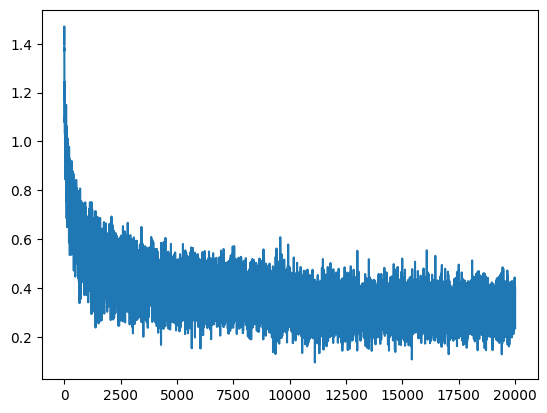

In [7]:
plt.plot(lossi)

In [ ]:
@torch.no_grad() # this decorator will disable gradient tracking inside this function, which is useful for inference and evaluation
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # Contact into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")


split_loss('train')
split_loss('val')



train loss: 2.0915
val loss: 2.0989


In [9]:
# Lets now Sample from our model

g = torch.Generator().manual_seed(2147483647 + 102) # for reproducability

for _ in range(20):

  out = []
  context = [0] * block_size # Initilise with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (37,100)
    logits = h @ W2 + b2 # 37,27
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

dharshini.
hamatriyyan.
bhakattag.
selvtungavidh.
chan.
vaimtrumaharshindu.
chanthan.
cpaya.
ayyakidyalath.
mathesh.
kaarejulith.
kagmisadhika.
shrarja.
joajanu.
kula.
poran.
arbak.
naru.
ruti.
kalash.
